# Creator crossover, 7-title subset (Substack-ready)

**Purpose**: a mobile-readable companion chart for "Post 2" (`research/foundations/Post 2 Draft.pdf`), specifically its unfinished "Problem 2" section — that genre/platform/market bins are leaky and don't cleanly contain what they claim to. The full 23x23 clustered heatmap in `research/inter_esports_dynamics/notebooks/creator_crossover.ipynb` makes that case at full resolution but isn't legible at phone width. This notebook does **not** duplicate that pipeline's logic wholesale — it recomputes the same query and the same `enrichment_ratio`/hypergeometric statistic (so the numbers are directly comparable to the full notebook, not a different metric that happens to look similar), restricted to seven titles chosen to carry the argument on a Substack page.

**Title selection, and why these seven**:
- **Counter-Strike, VALORANT, Rainbow Six Siege** — the exact tac-FPS/PC trio the draft uses as its running example ("in Brazil, ultimately Counter-Strike should crowd out VALORANT and Rainbow 6 Siege"). Showing their actual creator-overlap numbers gives that passage a real chart, not just a hypothetical.
- **League of Legends, Dota 2** — the "Classic Titles" the post's opening paragraph names directly; the MOBA pair every reader will already have a prior about.
- **Age of Empires II, StarCraft II** — originally picked because the parent notebook flagged this pair as the single strongest real signal in the full 23-title matrix. **Updated 2026-10-02**: with five weeks of data instead of two, that's no longer quite true at full scale — the parent notebook's own top rank now belongs to Guilty Gear -Strive-/Street Fighter 6 (5.48x), neither of which is in this seven-title subset, with Age of Empires II/StarCraft II close behind at 5.12x (p=1.5e-05). Within *this* seven-title subset it's still comfortably the strongest pair (nothing else here comes close to 1.0x, let alone 5x), which is the only claim this chart actually needs to make — it was never trying to represent the single strongest pair in all 23 titles, just a real cross-genre signal stronger than anything inside the genre boxes shown here. The exact figure will keep moving as more data accumulates. This is the payload cell for the "leaky vectors" argument: two titles nobody would group with the tac-FPS or MOBA titles above turn out to share far more creator overlap than titles inside the niche boxes the post is busy questioning.

**Not re-clustered.** The full notebook's hierarchical clustering is the right call at 23 titles (it surfaces groupings you wouldn't guess); at 7 hand-picked titles the grouping is already the point being made, so rows/columns are ordered by the three blocks above — tac-FPS, MOBA, RTS — so a reader's eye lands on the intended genre grouping immediately, before the numbers complicate it (§ Read, below).

**Same caveats as the parent notebook apply** — this is tier-2 (above-threshold, non-official) creator crossover, a proxy for creator supply, not a direct measure of viewer overlap; window now runs 2026-08-31 to 2026-10-02 (about five weeks, up from ~16 days on the previous pass).</cell id="51a5a990">


In [1]:
# Imports and repo path setup -- same pattern as every other notebook.
import sys
from itertools import combinations
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")


REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import yaml
from scipy.stats import hypergeom

from etl.db import get_connection

In [2]:
# The seven-title subset for this chart, and their display order (grouped
# by block, not clustered -- see markdown above for why).
SUBSET_TITLE_IDS_ORDERED = [
    "counter_strike", "valorant", "rainbow_six_siege",   # tac-FPS / PC
    "league_of_legends", "dota2",                          # MOBA
    "age_of_empires_ii", "starcraft2",                     # RTS
]

with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]

active_titles = [t for t in titles_config if t.get("is_active")]
display_name_by_id = {t["id"]: t["display_name"] for t in active_titles}
all_title_ids = [t["id"] for t in active_titles]

missing = [tid for tid in SUBSET_TITLE_IDS_ORDERED if tid not in display_name_by_id]
assert not missing, f"title id(s) not found in config/titles.yaml: {missing}"

[display_name_by_id[t] for t in SUBSET_TITLE_IDS_ORDERED]

['Counter-Strike 2',
 'VALORANT',
 'Rainbow Six Siege',
 'League of Legends',
 'Dota 2',
 'Age of Empires II',
 'StarCraft II']

In [3]:
# Load tier-2 (above-threshold, non-official) stream records -- identical
# query to research/inter_esports_dynamics/notebooks/creator_crossover.ipynb.
conn = get_connection()
window_start, window_end = conn.execute(
    "SELECT MIN(captured_at), MAX(captured_at) FROM viewership_snapshots"
).fetchone()
print(f"viewership_snapshots window: {window_start} to {window_end}")

raw_rows = conn.execute(
    """
    SELECT channel_id, title_id, viewer_count
    FROM viewership_snapshots
    WHERE is_official_broadcast = 0
    """
).fetchall()
conn.close()

raw_df = pd.DataFrame(raw_rows, columns=["channel_id", "title_id", "viewer_count"])
channel_title_df = (
    raw_df.groupby(["channel_id", "title_id"])["viewer_count"].sum().rename("viewer_time").reset_index()
)

print(f"{channel_title_df['channel_id'].nunique()} distinct above-threshold, non-official channels seen")

viewership_snapshots window: 2026-08-31T10:13:48Z to 2026-10-02T12:18:26Z


296583 distinct above-threshold, non-official channels seen


In [4]:
# Enrichment ratio + hypergeometric p-value for every pair -- population is
# ALL 23 titles' channels (n_total_channels), same as the full notebook, so
# these numbers are directly comparable to that notebook's pair_rollup, not
# a different statistic computed over a smaller, self-contained population.
titles_per_channel = channel_title_df.groupby("channel_id")["title_id"].nunique()
crossover_channel_ids = titles_per_channel[titles_per_channel > 1].index
crossover_df = channel_title_df[channel_title_df["channel_id"].isin(crossover_channel_ids)]

n_total_channels = channel_title_df["channel_id"].nunique()
total_channels_by_title = channel_title_df.groupby("title_id")["channel_id"].nunique()

titles_by_channel = crossover_df.groupby("channel_id")["title_id"].apply(set)
pair_channels: dict[tuple[str, str], set] = {}
for channel_id, title_set in titles_by_channel.items():
    for a, b in combinations(sorted(title_set), 2):
        pair_channels.setdefault((a, b), set()).add(channel_id)


def hypergeom_pvalue(shared: int, total_a: int, total_b: int, population: int) -> float:
    """One-sided p-value in whichever direction the overlap actually went --
    identical to the parent notebook's implementation."""
    dist = hypergeom(population, total_a, total_b)
    expected = total_a * total_b / population
    if shared >= expected:
        return float(dist.sf(shared - 1))
    return float(dist.cdf(shared))


subset_pairs = list(combinations(SUBSET_TITLE_IDS_ORDERED, 2))
pair_rows = []
for a, b in subset_pairs:
    key = tuple(sorted((a, b)))
    shared_channel_ids = pair_channels.get(key, set())
    shared = len(shared_channel_ids)
    total_a, total_b = total_channels_by_title.get(a, 0), total_channels_by_title.get(b, 0)
    expected_shared = total_a * total_b / n_total_channels if n_total_channels else float("nan")
    pair_rows.append({
        "title_a": display_name_by_id[a],
        "title_b": display_name_by_id[b],
        "shared_crossover_channels": shared,
        "total_channels_a": total_a,
        "total_channels_b": total_b,
        "expected_shared": round(expected_shared, 2),
        "enrichment_ratio": round(shared / expected_shared, 2) if expected_shared > 0 else float("nan"),
        "hypergeometric_p_value": hypergeom_pvalue(shared, total_a, total_b, n_total_channels) if total_a and total_b else float("nan"),
    })

subset_pair_df = pd.DataFrame(pair_rows).sort_values("enrichment_ratio", ascending=False).reset_index(drop=True)
subset_pair_df

,title_a,title_b,shared_crossover_channels,total_channels_a,total_channels_b,expected_shared,enrichment_ratio,hypergeometric_p_value
0,Age of Empires II,StarCraft II,11,841,758,2.15,5.12,1.465788e-05
1,Counter-Strike 2,Dota 2,1228,29079,13599,1333.34,0.92,8.833016e-04
2,Dota 2,StarCraft II,20,13599,758,34.76,0.58,4.056258e-03
3,VALORANT,League of Legends,4423,61398,38518,7973.92,0.55,0.000000e+00
4,League of Legends,Age of Empires II,44,38518,841,109.22,0.40,6.034013e-14
5,League of Legends,StarCraft II,34,38518,758,98.44,0.35,2.311681e-15
6,Counter-Strike 2,VALORANT,1900,29079,61398,6019.87,0.32,0.000000e+00
7,Counter-Strike 2,League of Legends,1121,29079,38518,3776.56,0.30,0.000000e+00
8,Counter-Strike 2,Age of Empires II,19,29079,841,82.46,0.23,2.911515e-18
9,VALORANT,Rainbow Six Siege,771,61398,16906,3499.85,0.22,0.000000e+00


In [5]:
# Build the 7x7 matrix in the fixed block order (tac-FPS / MOBA / RTS),
# diagonal masked out (not a meaningful value -- see parent notebook).
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma

# Shortened for the mobile chart only -- does not touch display_name_by_id,
# which stays the source of truth everywhere else (tables, joins, titles).
CHART_LABEL = {
    "counter_strike": "Counter-Strike",
    "valorant": "VALORANT",
    "rainbow_six_siege": "R6 Siege",
    "league_of_legends": "League of Legends",
    "dota2": "Dota 2",
    "age_of_empires_ii": "AoE II",
    "starcraft2": "StarCraft II",
}
labels = [CHART_LABEL[t] for t in SUBSET_TITLE_IDS_ORDERED]
n = len(SUBSET_TITLE_IDS_ORDERED)

id_by_label_name = {display_name_by_id[t]: t for t in SUBSET_TITLE_IDS_ORDERED}
matrix = np.full((n, n), np.nan)
for _, row in subset_pair_df.iterrows():
    i = SUBSET_TITLE_IDS_ORDERED.index(id_by_label_name[row["title_a"]])
    j = SUBSET_TITLE_IDS_ORDERED.index(id_by_label_name[row["title_b"]])
    matrix[i, j] = row["enrichment_ratio"]
    matrix[j, i] = row["enrichment_ratio"]
np.fill_diagonal(matrix, np.nan)

masked_matrix = ma.masked_invalid(matrix)
masked_matrix

masked_array(
  data=[[--, 0.32, 0.2, 0.3, 0.92, 0.23, 0.2],
        [0.32, --, 0.22, 0.55, 0.14, 0.07, 0.09],
        [0.2, 0.22, --, 0.14, 0.02, 0.04, 0.02],
        [0.3, 0.55, 0.14, --, 0.08, 0.4, 0.35],
        [0.92, 0.14, 0.02, 0.08, --, 0.21, 0.58],
        [0.23, 0.07, 0.04, 0.4, 0.21, --, 5.12],
        [0.2, 0.09, 0.02, 0.35, 0.58, 5.12, --]],
  mask=[[ True, False, False, False, False, False, False],
        [False,  True, False, False, False, False, False],
        [False, False,  True, False, False, False, False],
        [False, False, False,  True, False, False, False],
        [False, False, False, False,  True, False, False],
        [False, False, False, False, False,  True, False],
        [False, False, False, False, False, False,  True]],
  fill_value=1e+20)

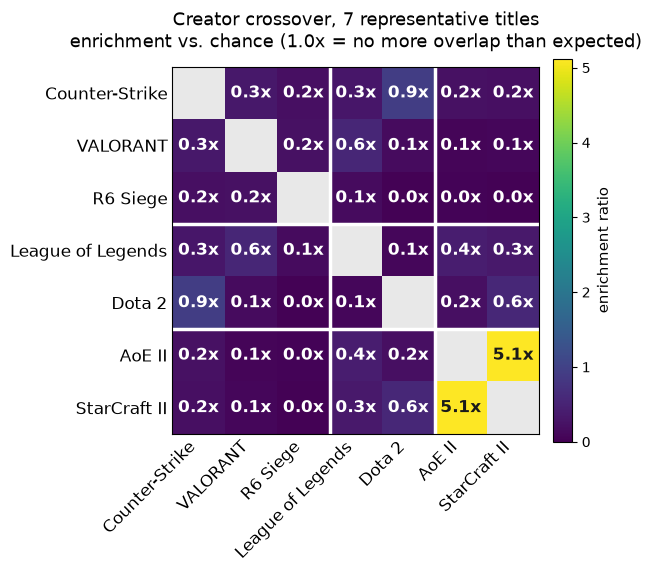

In [6]:
# Mobile-readable chart: square, large type, every cell annotated with its
# own enrichment ratio (feasible at 7x7, not at 23x23 -- that's the actual
# reason this needs its own chart rather than just cropping the big one),
# viridis kept for visual consistency with the parent notebook's own
# heatmap and because it's colorblind-safe as a perceptually-uniform
# sequential scale even though it isn't a literal single hue.
BLOCK_BOUNDARIES = [3, 5]  # after tac-FPS (3 titles), after MOBA (2 titles)

fig, ax = plt.subplots(figsize=(6.4, 6.4))
cmap = plt.get_cmap("viridis").copy()
cmap.set_bad(color="#e8e8e8")  # masked diagonal -> light gray, not a color-scale value

vmax = np.nanmax(matrix)
im = ax.imshow(masked_matrix, cmap=cmap, vmin=0, vmax=vmax, aspect="equal")

ax.set_xticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=12)
ax.set_yticks(range(n))
ax.set_yticklabels(labels, fontsize=12)
ax.tick_params(length=0)

# Direct value labels -- text color flips for readability against viridis's
# range (white on the dark purple low end, dark on the bright yellow high end).
norm = plt.Normalize(vmin=0, vmax=vmax)
for i in range(n):
    for j in range(n):
        val = matrix[i, j]
        if np.isnan(val):
            continue
        text_color = "white" if norm(val) < 0.6 else "#1a1a1a"
        ax.text(j, i, f"{val:.1f}x", ha="center", va="center", fontsize=12.5, color=text_color, fontweight="bold")

# Thin white block-divider lines so the tac-FPS / MOBA / RTS grouping reads
# at a glance, not just from axis order.
for b in BLOCK_BOUNDARIES:
    ax.axhline(b - 0.5, color="white", linewidth=2.5)
    ax.axvline(b - 0.5, color="white", linewidth=2.5)

ax.set_title("Creator crossover, 7 representative titles\nenrichment vs. chance (1.0x = no more overlap than expected)", fontsize=13, pad=14)
cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.03)
cbar.set_label("enrichment ratio", fontsize=11)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(Path.cwd() / "_creator_crossover_subset_mobile.png", dpi=200, bbox_inches="tight")
plt.show()

### Read

**Updated 2026-10-02** (figures below recomputed on the five-week window; no claim in this section reversed, numbers shifted slightly):

**The genre-mate pairs don't just fail to stand out — they sit at or below the chance baseline.** Every pair inside the tac-FPS trio (Counter-Strike/VALORANT/R6 Siege, 0.2–0.3x) and the MOBA pair (League of Legends/Dota 2, 0.08x) comes in *below* 1.0x — less creator overlap than two titles of their respective pool sizes would share if crossover were random. Counter-Strike's single highest-enrichment partner on this chart isn't VALORANT or R6 Siege, it's Dota 2 (0.92x, up from 0.76x last pass — drifting toward, not away from, the chance baseline) — still sub-chance, but the closest any pair gets outside the one real signal below. That's a stronger version of Post 2's Problem 2 than "the boxes are leaky at the edges": on this evidence, the boxes aren't doing any *positive* work at all — nothing in this set of genre-mates shows a shared audience-of-creators beyond what pool size alone would predict.

**Age of Empires II and StarCraft II is still the one real, unambiguous signal on this chart** — enrichment_ratio=5.12, p=1.5e-05 (up from ≈5.0, p≈6e-4 last pass) — between two titles that share nothing in the genre/platform/market taxonomy except being real-time, keyboard-and-mouse strategy games from the same console-less era. The chart's block dividers group titles by the taxonomy Post 2 is questioning; the numbers inside those blocks argue against the taxonomy, and the one bright cell sits entirely outside it. That's the concrete version of the draft's own hypothetical (would Call of Duty's single-player belong in the tac-FPS niche?) — from real data, not a thought experiment. (At full 23-title scale this pair is no longer the single strongest in the whole matrix — see the parent notebook's own 2026-10-02 update — but within this seven-title subset it still is, by a wide margin, which is the only claim this chart makes.)

**Caveats, unchanged from the parent notebook**: still tier-2/non-official crossover (a creator-supply signal, not direct viewer-overlap), and still subject to `config/channels.yaml` curation being incomplete (only 5 of 23 titles curated as of this run, so `is_official_broadcast=0` is doing less filtering than it eventually will). The exact ratios have already moved once between runs (AoE II/StarCraft II: 6.89 → ≈5.0 → 5.12 across three passes) — re-run before treating any of today's figures as settled, same discipline `fandom_and_niche_model` already applies to its own directional findings.</cell id="63b0f991">
